# Importação e visualização do banco de dados

In [48]:
#1. Importar as bibliotecas necessárias:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
%matplotlib inline

np.random.seed(0)


In [49]:
#2. Importar os dados e realizar uma análise inicial:
traino = pd.read_csv("./titanic/train.csv")
teste = pd.read_csv("./titanic/test.csv")

traino.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
#3. Análise exploratória preliminar:

# (a) Identificar colunas categóricas x numéricas (contínuas/discretas)

traino.info() #info do tipo de dados de cada valor da tabela



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [51]:
# (b) Verificar a presença de valores ausentes (NaN)
print("Valores ausentes no treino:")
print(traino.isnull().sum())
print()
print("Valores ausentes no teste:")
print(teste.isnull().sum())


Valores ausentes no treino:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Valores ausentes no teste:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [52]:
# (c) Criar novos dataframes contendo apenas as features numéricas (treino e teste)
Numericos = traino.select_dtypes(exclude=["object"])
Numericos_teste = teste.select_dtypes(exclude=["object"])

# (d) Remover linhas com valores faltantes no conjunto de treino
Numericos = Numericos.dropna()

# (e) Substituir os NaN por 0 no conjunto de teste
Numericos_teste = Numericos_teste.fillna(0)



# Exploração do banco de dados

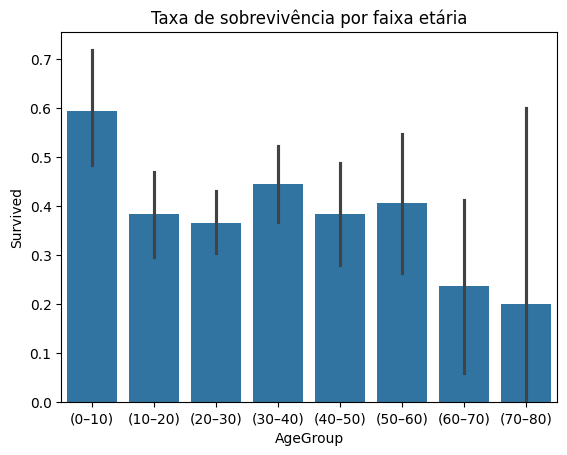

In [53]:
# 1. Análise da feature "Age"

Nomes_barras = ["(0–10)", "(10–20)", "(20–30)", "(30–40)", "(40–50)", "(50–60)", "(60–70)", "(70–80)"]
Faixas = [0, 10, 20, 30, 40, 50, 60, 70, 80]

idade_grupos = pd.cut(Numericos["Age"], bins=Faixas, labels=Nomes_barras)

Numericos["AgeGroup"] = idade_grupos

sns.barplot(data=Numericos, x="AgeGroup", y="Survived")
plt.title("Taxa de sobrevivência por faixa etária")
plt.show()


**Interpretação (Age):** a quantidade de sobreviventes é maior na faixas de 0 a 10 anos,
indicando que houve maior cuidado com as crinças. As faixasde 20 a 50 seguem a media,
enquanto os mais idosos tem a ter taxas de sobrevivência mais baixas e com maior valor
de desvio, provavelmente por ter poucos idosos para usar como comparação  

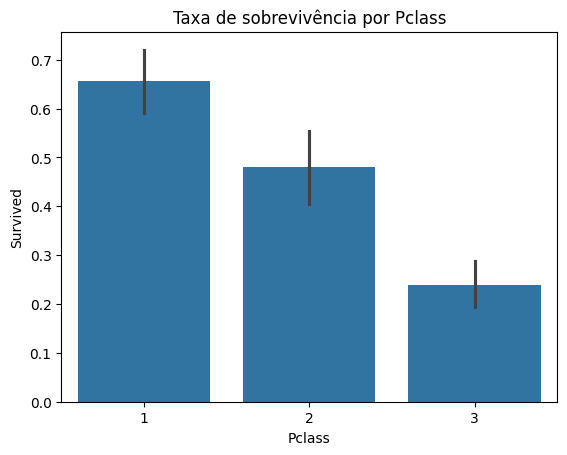

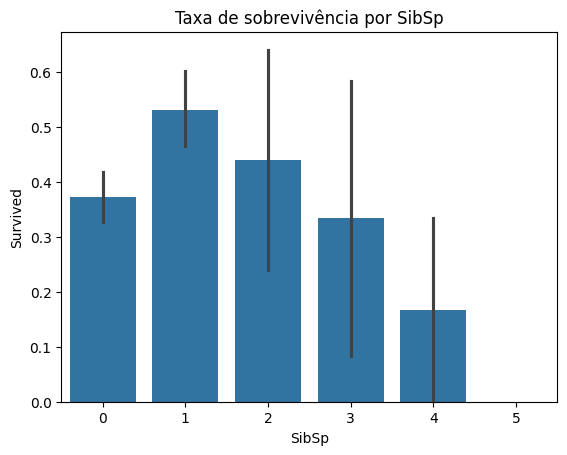

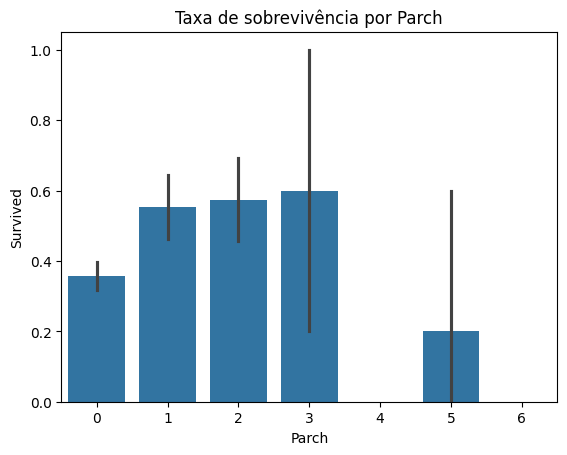

In [54]:
# 2. Analisar graficamente as demais features numéricas discretas (Fare fica de fora)
Analise_grafica = Numericos.copy()

features_discretas = ["Pclass", "SibSp", "Parch"] #features numéricas discretas:
                                                  #organizados em categorias

for feature in features_discretas:
    sns.barplot(data=Analise_grafica, x=feature, y="Survived")
    plt.title(f"Taxa de sobrevivência por {feature}")
    plt.show()


**Interpretações:**
- **Pclass:** quanto melhor a classe, maior a taxa de sobrevivência o que indica que aqueles com mais dinheiro
tinham mais acesso a Métodos
  .
- **SibSp** (irmãos/cônjuges): sobrevivência é maior para quem estava acompanhado,indicando cooperação entre conhecidos
  
- **Parch** (pais/filhos):mesmo padrão do SibSP 

# Treinamento do modelo e submissão das predições

In [55]:
# 1. Separação entre treino e validação
X = Numericos.drop(columns=["PassengerId", "Survived", "AgeGroup"])
y = Numericos["Survived"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=1)


In [56]:
# 2. Treinamento e validação do modelo
modelo = RandomForestClassifier(random_state=1)
modelo.fit(X_train, y_train)

predict_val = modelo.predict(X_val)
accuracy = accuracy_score(y_val, predict_val)
print("precissao na validação:", accuracy)


precissao na validação: 0.7342657342657343


**Discussão:** a precisao obtida foi de 0.73 que e' um bom resultado considerando que
nao foi usado paremetros nao numeros,como o genero da pessoa.

In [57]:
# 3. Geração e submissão da predição

# Treinar novamente, agora com TODOS os dados de treino já limpos (sem NaN)
modelo2 = RandomForestClassifier(random_state=1)

X_total = Numericos.drop(columns=["PassengerId", "Survived", "AgeGroup"])
y_total = Numericos["Survived"]
modelo2.fit(X_total, y_total)

# Guardar os PassengerId do teste
PassengerId = Numericos_teste["PassengerId"]

# Selecionar as mesmas colunas usadas no treino, já com NaN tratado (fillna(0))
X_test_final = Numericos_teste[X_total.columns]


# Fazer as previsões
predict_final = modelo2.predict(X_test_final)



# Criar DataFrame para submissão
df = pd.DataFrame({
    "PassengerId": PassengerId,
    "Survived": predict_final
})

print(df.head())
df.to_csv("submission.csv", index=False)


   PassengerId  Survived
0          892         0
1          893         0
2          894         1
3          895         1
4          896         0
